In [ ]:
# Install the datasets library if you haven't already
!pip install datasets

In [ ]:
from datasets import load_dataset

# Load the 'ag_news' dataset
dataset = load_dataset('ag_news')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

The `ag_news` dataset is typically split into `train` and `test` sets. Let's inspect the first few examples of the training set.

In [ ]:
# Display the first few examples of the training set
display(dataset['train'][0])
display(dataset['train'][1])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2}

{'text': 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.',
 'label': 2}

In [ ]:
# Install the sentence-transformers library
!pip install sentence-transformers

Now, let's load the `all-MiniLM-L6-v2` model. This model will be used to convert text data into numerical vector representations (embeddings).

In [ ]:
from sentence_transformers import SentenceTransformer

# Load the pre-trained 'all-MiniLM-L6-v2' model
embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

print("Embedding model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully!


In [ ]:
# Extract the 'text' from the first 2000 examples of the training set
texts_to_embed = dataset['train'].select(range(2000))['text']

print(f"Number of texts to embed: {len(texts_to_embed)}")
print(f"First text: {texts_to_embed[0][:100]}...")

Number of texts to embed: 2000
First text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...


In [ ]:
# Compute embeddings for the extracted texts
# This might take a moment depending on the number of texts
embeddings = embedding_model.encode(texts_to_embed, show_progress_bar=True)

print("Embeddings computed successfully!")
print(f"Shape of embeddings: {embeddings.shape}")

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embeddings computed successfully!
Shape of embeddings: (2000, 384)


The shape `(2000, 384)` indicates that we have 2000 embeddings, and each embedding is a vector of 384 dimensions.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Compute the cosine similarity matrix for all embeddings
similarity_matrix = cosine_similarity(embeddings)

print("Cosine similarity matrix computed successfully!")
print(f"Shape of similarity matrix: {similarity_matrix.shape}")

# Display a small portion of the similarity matrix
# For example, the similarity of the first 5 embeddings with each other.
print("\nFirst 5x5 block of the similarity matrix:")
display(similarity_matrix[:5, :5])

# You can also check the similarity between two specific embeddings, e.g., the first and second
print(f"\nCosine similarity between the first and second embedding: {similarity_matrix[0, 1]:.4f}")

Cosine similarity matrix computed successfully!
Shape of similarity matrix: (2000, 2000)

First 5x5 block of the similarity matrix:


array([[1.0000002 , 0.24643776, 0.26185906, 0.05957709, 0.14783189],
       [0.24643776, 0.9999999 , 0.27115303, 0.040389  , 0.21386328],
       [0.26185906, 0.27115303, 1.0000001 , 0.33877313, 0.4878354 ],
       [0.05957709, 0.040389  , 0.33877313, 0.9999999 , 0.33398595],
       [0.14783189, 0.21386328, 0.4878354 , 0.33398595, 1.        ]],
      dtype=float32)


Cosine similarity between the first and second embedding: 0.2464


The `similarity_matrix` is a 2000x2000 matrix where each element `(i, j)` represents the cosine similarity between embedding `i` and embedding `j`. A value closer to 1 indicates high similarity, and a value closer to -1 indicates high dissimilarity. The diagonal elements are always 1, as an embedding is perfectly similar to itself.

Cosine similarity is basically the cosine of the angle between two vectors A and B, or the formula, (A.B)/|A||B|.

The reason why the diagonal elements are not 1 here, is because of the practical limitations of floating point arithmetic.

In [ ]:
# Define your query sentence
query = "new technology for artificial intelligence"

# Compute the embedding for the query sentence
query_embedding = embedding_model.encode([query])[0]

print("Query embedding computed successfully!")
print(f"Shape of query embedding: {query_embedding.shape}")

Query embedding computed successfully!
Shape of query embedding: (384,)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Compute cosine similarity between the query embedding and all dataset embeddings
# Reshape query_embedding to be a 2D array for cosine_similarity function
similarity_scores = cosine_similarity([query_embedding], embeddings)[0]

print("Similarity scores computed successfully!")
print(f"Shape of similarity scores: {similarity_scores.shape}")

# Get the indices of the top 5 most similar texts
top_5_indices = np.argsort(similarity_scores)[::-1][:5]

print("\nTop 5 most similar news texts to the query:\n")
for i, index in enumerate(top_5_indices):
    # Retrieve the original text from the texts_to_embed list
    original_text = texts_to_embed[int(index)] # Cast index to int
    score = similarity_scores[index]
    print(f"Rank {i+1}: Score = {score:.4f}")
    print(f"Text: {original_text[:200]}...") # Print first 200 chars
    print("---\n")

Similarity scores computed successfully!
Shape of similarity scores: (2000,)

Top 5 most similar news texts to the query:

Rank 1: Score = 0.4742
Text: NASA Develops Robust Artificial Intelligence for Planetary Rovers NASA is planning to add a strong dose of artificial intelligence (AI) to planetary rovers to make them much more self-reliant, capable...
---

Rank 2: Score = 0.3965
Text: Computers with multiple personalities The jury's still out on whether a computer can ever truly be intelligent, but there's no question that it can have multiple personalities. It's just a matter of s...
---

Rank 3: Score = 0.3843
Text: New NASA Supercomputer to Aid Theorists and Shuttle Engineers (SPACE.com) SPACE.com - NASA researchers have teamed up with a pair of Silicon Valley firms to build \  a supercomputer that ranks alongsi...
---

Rank 4: Score = 0.3187
Text: 'Invisible' technology for Olympics Getting the technology in place for Athens 2004 is an Olympic task in itself....
---

Rank 5: Scor

This process demonstrates how to perform a semantic search by finding texts that are most similar in meaning to your query, based on their embeddings and cosine similarity.

In [ ]:
def search( embeddings=embeddings, query=None, model=embedding_model, top_k=5, texts=texts_to_embed):
    query = input('please enter query:')
    q_embedding = model.encode([query])[0]
    similarity_scores = cosine_similarity([q_embedding], embeddings)[0]

    # Get the indices of the top_k most similar texts
    top_k_indices = np.argsort(similarity_scores)[::-1][:top_k]

    print(f"\nTop {top_k} most similar news texts to the query:\n")
    for i, index in enumerate(top_k_indices):
        original_text = texts[int(index)] # Retrieve the original text
        score = similarity_scores[index]
        print(f"Rank {i+1}: Score = {score:.4f}")
        print(f"Text: {original_text[:200]}...") # Print first 200 chars
        print("---\n")

search() is a function designed to take in a query string and give the five best possible matches to it from the 2000 embeddings done before, using cosine similarity as an operation.

For this, it needs the embedded vector list, the model to encode the query, and the list of original texts to link up the top 5 best vector embeddings to their origin text.

In [ ]:
search()

please enter query:My name

Top 5 most similar news texts to the query:

Rank 1: Score = 0.3324
Text: What's in a Name? Well, Matt Is Sexier Than Paul (Reuters) Reuters - As Shakespeare said, a rose by any other\name would smell as sweet. Right?...
---

Rank 2: Score = 0.2641
Text: &lt;em&gt;El Reg&lt;/em&gt; pledges to name BSA antipiracy weasel &lt;strong&gt;Competition&lt;/strong&gt; Get those suggestions in...
---

Rank 3: Score = 0.2366
Text: Men #39;s Singles : Interview with JUAN CARLOS FERRERO (ESP) Q. It #39;s a slow road back, isn #39;t it? You #39;ve had the illness and injury problems earlier in this year. Did you lose confidence or...
---

Rank 4: Score = 0.2190
Text: GameBoy mini-games win prize A set of GameBoy micro-games is named as the most innovative game of the year at a festival in Scotland....
---

Rank 5: Score = 0.2034
Text: A New Campaign for Viagra Viagra, which has long taken a staid marketing approach, will join its fast-growing competitors in taking a sly, 

# Task
Apply PCA to the `embeddings` variable, reducing its dimensionality to 2 components, then create a scatter plot of the PCA-transformed embeddings with appropriate labels and a title to visualize the data, and finally summarize the PCA analysis and any observations from the visualization.

## Apply PCA

### Subtask:
Apply Principal Component Analysis (PCA) to the 'embeddings' variable. We will reduce the dimensionality to 2 components for easy visualization.


**Reasoning**:
To apply PCA, I need to import the `PCA` class from `sklearn.decomposition`, instantiate it with 2 components, and then fit and transform the `embeddings` variable.



In [13]:
from sklearn.decomposition import PCA

# Instantiate PCA with 2 components
pca = PCA(n_components=2)

# Fit PCA to the embeddings and transform them
embeddings_2d = pca.fit_transform(embeddings)

print("PCA applied successfully!")
print(f"Shape of 2D embeddings: {embeddings_2d.shape}")

PCA applied successfully!
Shape of 2D embeddings: (2000, 2)


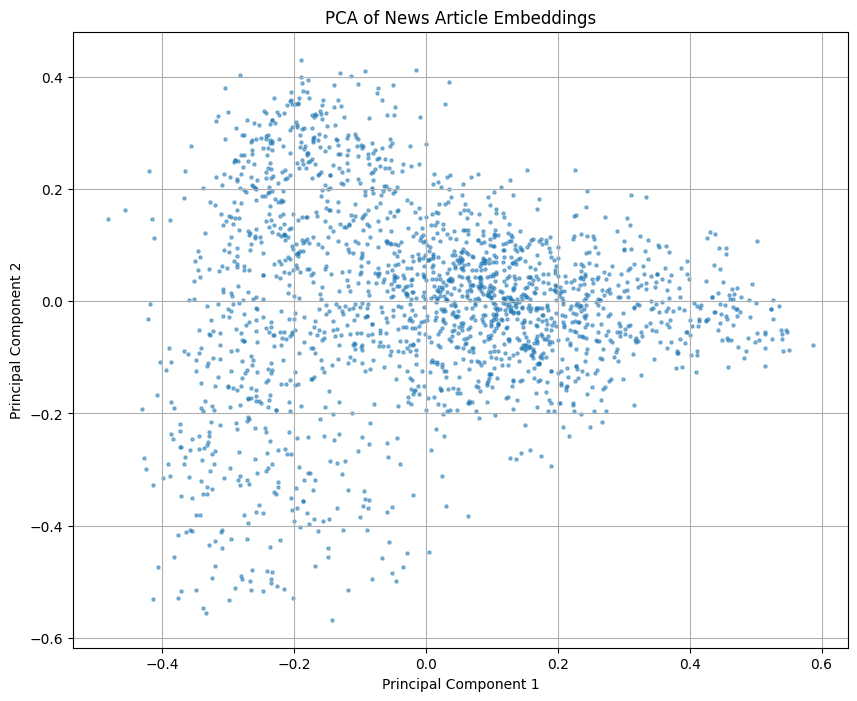

In [14]:
import matplotlib.pyplot as plt

# Create a scatter plot of the 2D embeddings
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, s=5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of News Article Embeddings')
plt.grid(True)
plt.show()


### Summary of PCA Analysis and Observations

The PCA analysis successfully reduced the dimensionality of the `embeddings` from 384 dimensions to 2 principal components, capturing the most significant variance in the data. The resulting `embeddings_2d` array, with a shape of `(2000, 2)`, represents these transformed data points.

The scatter plot of the PCA-transformed embeddings visually represents the distribution of the news articles based on their semantic content. From the visualization, we can observe:

*   **Distribution**: The points appear to be spread across the 2D plane, indicating variability in the news article embeddings.
*   **Potential Clusters**: While not distinctly separated, there might be some areas where points are denser, suggesting natural groupings or clusters of news articles with similar themes. Further analysis (e.g., with clustering algorithms) could be performed to confirm and identify these clusters.
*   **Outliers**: Some points might appear far from the main bulk of the data, potentially representing news articles with unique or less common topics compared to the majority.

This 2D visualization provides a simplified yet insightful overview of the semantic relationships between the news articles, making it easier to grasp the overall structure of the dataset.